In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.preprocessing import StandardScaler
pd.set_option('display.precision',3)

In [3]:
df=pd.read_csv('aapl_data.csv',sep=',',skiprows=[1,2])
df.rename(columns={'Price':'Date'},inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,2021-03-25,902.986,931.348,900.061,931.348,22001648
1,2021-03-26,904.437,913.074,894.937,912.304,20180202
2,2021-03-30,920.148,929.035,903.031,910.490,20441701
3,2021-03-31,908.268,929.489,906.409,915.024,16250796
4,2021-04-01,916.770,920.465,908.291,915.024,11723312


In [4]:
df['prev_close']=df['Close'].shift(1)
df.head()

,Date,Close,High,Low,Open,Volume,prev_close
0,2021-03-25,902.986,931.348,900.061,931.348,22001648,NaN
1,2021-03-26,904.437,913.074,894.937,912.304,20180202,902.986
2,2021-03-30,920.148,929.035,903.031,910.490,20441701,904.437
3,2021-03-31,908.268,929.489,906.409,915.024,16250796,920.148
4,2021-04-01,916.770,920.465,908.291,915.024,11723312,908.268


In [5]:
df['returns']=(df['Close']-df['prev_close'])/df['prev_close']
df = df.dropna().copy()
df.head()

,Date,Close,High,Low,Open,Volume,prev_close,returns
1,2021-03-26,904.437,913.074,894.937,912.304,20180202,902.986,0.002
2,2021-03-30,920.148,929.035,903.031,910.490,20441701,904.437,0.017
3,2021-03-31,908.268,929.489,906.409,915.024,16250796,920.148,-0.013
4,2021-04-01,916.770,920.465,908.291,915.024,11723312,908.268,0.009
5,2021-04-05,903.507,918.198,889.677,918.176,14875099,916.770,-0.014


In [ ]:

return_l = df['returns'].tolist()
close_l = df['Close'].tolist()

X = []
y = []

for i in range(2, len(return_l) - 1):
    f = [
        return_l[i-2], return_l[i-1], return_l[i],  #3 days' returns
        np.std([return_l[i-2], return_l[i-1], return_l[i]],ddof=1), #3 days' voltality
        close_l[i]-np.mean([close_l[i-2],close_l[i-1],close_l[i]]) #
    ]
    X.append(f)

    if close_l[i+1]>=close_l[i]:
        y.append(1)
    else:
        y.append(0)


X = np.array(X)
y = np.array(y)

In [7]:
y[:11]

array([1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, shuffle=False)
scaler5=StandardScaler()
X_train = scaler5.fit_transform(X_train)
X_test = scaler5.transform(X_test)

weighted_model=LogisticRegression(class_weight='balanced')
weighted_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [ ]:
y_pred=model.predict(X_test)
accuracy_score(y_test,y_pred)

0.5308641975308642

In [9]:
y_pred = weighted_model.predict(X_test)
accuracy_score( y_test, y_pred)

0.5060728744939271

In [10]:
confusion_matrix(y_test, y_pred)

array([[82, 38],
       [84, 43]])

### aaaa

In [19]:
df['volatility_5'] = df['returns'].rolling(5).std()
df['volatility_3'] = df['returns'].rolling(3).std()

In [13]:
df['sma_5'] = df['Close'].rolling(5).mean()
df['sma_20'] = df['Close'].rolling(20).mean()
df['sma_crossover'] = (df['sma_5'] > df['sma_20']).astype(int)

In [14]:
delta = df['Close'].diff()          # daily change in price
gain = delta.clip(lower=0)          # keep only positive changes
loss = -delta.clip(upper=0)         # keep only negative changes (flip sign)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / (avg_loss + 1e-9)   # ratio of avg gain to avg loss
df['rsi'] = 100 - (100 / (1 + rs))

In [15]:
high_10 = df['Close'].rolling(10).max()
low_10 = df['Close'].rolling(10).min()

df['price_position'] = (df['Close'] - low_10) / (high_10 - low_10 + 1e-9)

In [16]:
df['price_position'].describe()

count    1226.000
mean        0.530
std         0.383
min         0.000
25%         0.144
50%         0.556
75%         0.943
max         1.000
Name: price_position, dtype: float64

In [22]:
df = df.dropna().copy()
df.tail()

,Date,Close,High,Low,Open,Volume,prev_close,returns,volatility_5,sma_5,sma_20,sma_crossover,rsi,price_position,volatility_3
1231,2026-03-18,1408.1,1412.9,1397.2,1397.2,9559327,1397.6,0.008,0.007,1394.74,1401.005,0,52.145,0.633,0.004
1232,2026-03-19,1384.8,1415.7,1376.1,1388.0,16498373,1408.1,-0.017,0.011,1393.26,1398.180,0,45.394,0.095,0.013
1233,2026-03-20,1414.4,1430.0,1396.1,1398.0,22994918,1384.8,0.021,0.014,1400.00,1398.425,1,54.012,0.778,0.019
1234,2026-03-23,1407.8,1415.6,1391.0,1400.0,18979554,1414.4,-0.005,0.014,1402.54,1397.845,1,61.008,0.804,0.019
1235,2026-03-24,1411.8,1422.4,1406.6,1420.0,18620893,1407.8,0.003,0.014,1405.38,1397.035,1,65.378,0.923,0.013


In [23]:

return_l = df['returns'].tolist()
close_l = df['Close'].tolist()
vol_3l = df['volatility_3'].tolist()
vol_5l = df['volatility_5'].tolist()
rsi_l = df['rsi'].tolist()
sma_l = df['sma_crossover'].tolist()
pp_l = df['price_position'].tolist()


X = []
y = []

for i in range(2, len(return_l) - 1):
    f = [
        return_l[i-2], return_l[i-1], return_l[i],
        close_l[i]-np.mean([close_l[i-2],close_l[i-1],close_l[i]]),
        vol_3l[i], vol_5l[i], rsi_l[i], sma_l[i], pp_l[i]
    ]
    X.append(f)

    if close_l[i+1]>=close_l[i]:
        y.append(1)
    else:
        y.append(0)


X = np.array(X)
y = np.array(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, shuffle=False)
scaler=StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model= LogisticRegression(class_weight='balanced',)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [26]:
y_pred=model.predict(X_test)
accuracy_score(y_test,y_pred)

0.5308641975308642

In [27]:
confusion_matrix(y_test,y_pred)

array([[61, 56],
       [58, 68]])

In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"Mean accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})")

Mean accuracy: 0.4897 (+/- 0.0114)


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Down', 'Up']))

              precision    recall  f1-score   support

        Down       0.51      0.52      0.52       117
          Up       0.55      0.54      0.54       126

    accuracy                           0.53       243
   macro avg       0.53      0.53      0.53       243
weighted avg       0.53      0.53      0.53       243



In [30]:
from sklearn.metrics import roc_auc_score
y_proba = model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

ROC-AUC: 0.5575


### backtesting

In [ ]:
train_size = len(X_train)

strategy_returns = []
bah_returns = []

for i in range(len(X_test)):
    ypr= model.predict(X_test[i])
    
    # actual return (aligned)
    actual_ret = (close_l[train_size + i + 1] - close_l[train_size + i]) / close_l[train_size + i]
    
    # strategy
    if ypr[0] == 1:
        strategy_returns.append(actual_ret)
    else:
        strategy_returns.append(0)  # important
    
    # buy & hold
    bah_returns.append(actual_ret)


In [42]:
import numpy as np

cumulative_strategy = np.cumprod([1 + r for r in strategy_returns])
cumulative_bah = np.cumprod([1 + r for r in bah_returns])
cumulative_strategy[-1], cumulative_bah[-1]

(np.float64(0.9300239847471266), np.float64(1.110975649512528))

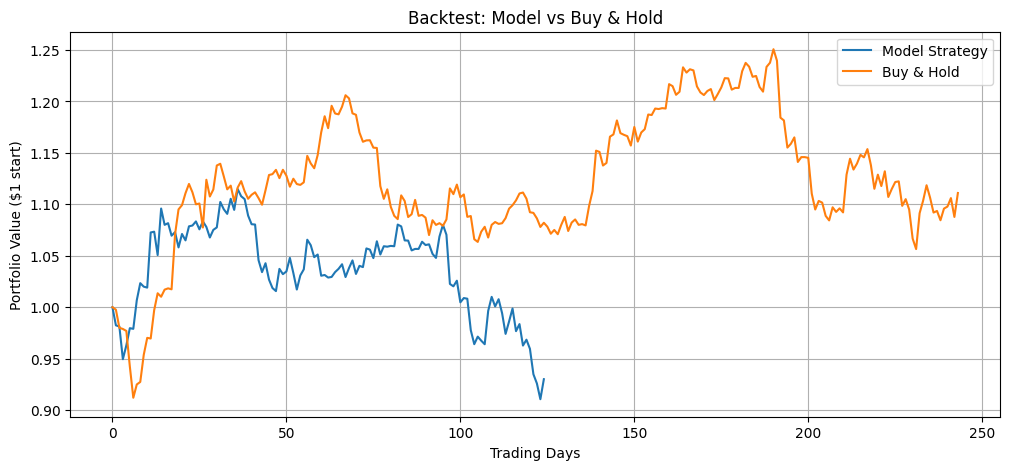

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot([1] + list(cumulative_strategy), label='Model Strategy')
plt.plot([1] + list(cumulative_bah), label='Buy & Hold')
plt.title('Backtest: Model vs Buy & Hold')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value ($1 start)')
plt.legend()
plt.grid(True)
plt.show()